In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [9]:
np.random.seed(42)

data = []

for i in range(3000):
    x = np.random.uniform(0, 100)
    y = np.random.uniform(0, 100)

    distance = np.sqrt((x - 50)**2 + (y - 50)**2)
    speed = np.random.uniform(0, 5)
    crowd_density = np.random.uniform(0, 1)

    separated = 1 if (distance > 30 and crowd_density > 0.6) else 0

    data.append([distance, speed, crowd_density, separated])

df = pd.DataFrame(data, columns=['distance', 'speed', 'crowd_density', 'separated'])

df.head()

,distance,speed,crowd_density,separated
0,46.784994,3.659970,0.598658,0
1,48.648016,0.290418,0.866176,1
2,23.134054,0.102922,0.969910,0
3,43.962131,0.909125,0.183405,0
4,19.731695,2.159725,0.291229,0


In [10]:
df.describe()
df['separated'].value_counts()

separated
0    2199
1     801
Name: count, dtype: int64

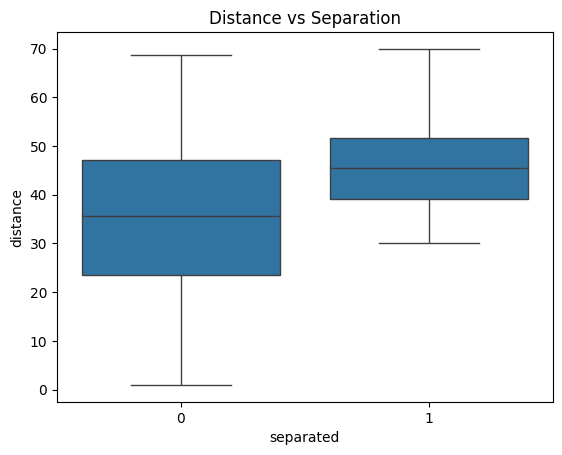

In [11]:
sns.boxplot(x='separated', y='distance', data=df)
plt.title("Distance vs Separation")
plt.show()

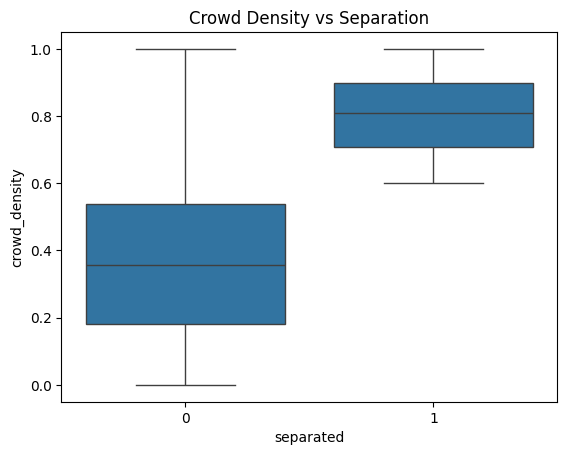

In [12]:
sns.boxplot(x='separated', y='crowd_density', data=df)
plt.title("Crowd Density vs Separation")
plt.show()

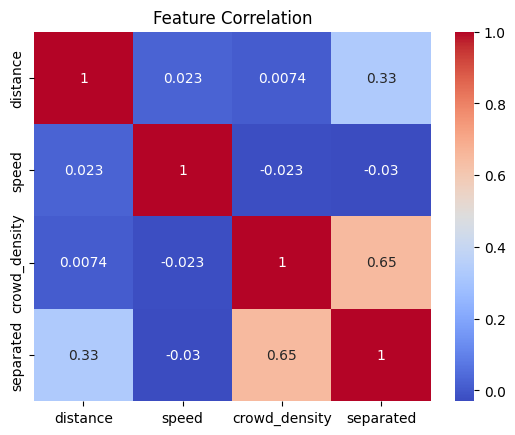

In [13]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [14]:
X = df[['distance', 'speed', 'crowd_density']]
y = df['separated']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [15]:
rf = RandomForestClassifier()
lr = LogisticRegression()
dt = DecisionTreeClassifier()

rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [16]:
models = {"RandomForest": rf, "LogisticRegression": lr, "DecisionTree": dt}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


RandomForest
Accuracy: 0.9983333333333333
Confusion Matrix:
 [[445   0]
 [  1 154]]

LogisticRegression
Accuracy: 0.915
Confusion Matrix:
 [[417  28]
 [ 23 132]]

DecisionTree
Accuracy: 1.0
Confusion Matrix:
 [[445   0]
 [  0 155]]


Insights:
- Higher distance significantly increases separation risk
- High crowd density strongly correlates with separation
- Speed has moderate influence
- Random Forest performed best among models

In [17]:
sample = [[40, 2.5, 0.8]]

prediction = rf.predict(sample)
probability = rf.predict_proba(sample)

print("Prediction (1 = Lost):", prediction[0])
print("Probability:", probability[0])

Prediction (1 = Lost): 1
Probability: [0. 1.]


c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [18]:
import joblib
joblib.dump(rf, "crowd_model.pkl")

['crowd_model.pkl']